### ✅ Task 1: Evaluate AI Categorization Accuracy

Using the bookkeeper annotations as ground truth:

- Compare AI-generated  AssignedCategory with the corrected Category 
- Calculate precision, recall, F1 score for categorization (both overall and per-category if possible)
- Identify categories with highest and lowest accuracy

📎 *Bonus*: Visualize confusion between similar categories (e.g. “Chair Rental:Hair Chair” vs “Chair Rental:Lash Bed”)

In [103]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


- Compare AI-generated  AssignedCategory  with the corrected  Category 

In [104]:
df = pd.read_csv('Categorized_Transactions_Elle_Jan2025(in).csv')

print(f"\n📊 Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")

print(f"\n🔍 Missing values:")
print(df.isnull().sum())

has_corrections = df['Category'].notna()
ai_predictions = df['AssignedCategory'].notna()

print(f"\n📈 Correction Statistics:")
print(f"Total transactions: {len(df)}")
print(f"Transactions with AI predictions: {ai_predictions.sum()}")
print(f"Transactions with bookkeeper corrections: {has_corrections.sum()}")
print(f"Correction rate: {df['Category'].notna().mean()*100:.2f}%")



📊 Dataset Overview:
Shape: (776, 21)

Columns: ['accountId', 'date', 'name', 'amount', 'description', 'paymentChannel', 'type', 'Explaination', 'transactionId', 'AssignedCategory', 'ConfidenceScore', 'AccountNumber', 'TypeOfTransaction', 'Payee', 'Taxes', 'Type of Transaction', 'Payee/Vendor', 'Category', 'Account Number', 'Tax', 'Memo/Notes']

🔍 Missing values:
accountId                0
date                     0
name                     0
amount                   0
description              0
paymentChannel           0
type                     0
Explaination             0
transactionId            0
AssignedCategory         0
ConfidenceScore          0
AccountNumber            9
TypeOfTransaction       11
Payee                    5
Taxes                   38
Type of Transaction    705
Payee/Vendor           674
Category               606
Account Number         508
Tax                    512
Memo/Notes             446
dtype: int64

📈 Correction Statistics:
Total transactions: 776
Tran

- Calculate precision, recall, F1 score for categorization (both overall and per-category if possible)

In [105]:
def get_actuals_and_predictions():
    
    actuals = []
    predictions = []
    
    for _, row in df[ai_predictions].iterrows():
        ai_category = row['AssignedCategory']
        bookkeeper_category = row['Category']
        
        if pd.notna(bookkeeper_category):
            actuals.append(bookkeeper_category)
        else:
            actuals.append(ai_category)
            
        predictions.append(ai_category)
    
    return actuals, predictions

In [106]:
actuals, predictions = get_actuals_and_predictions()

In [107]:
def calculate_accuracy_metrics():
    

    # Get unique categories
    all_categories = list(set(actuals + predictions))
    
    # Calculate metrics
    precision = precision_score(actuals, predictions, average='weighted', zero_division=0)
    recall = recall_score(actuals, predictions, average='weighted', zero_division=0)
    f1 = f1_score(actuals, predictions, average='weighted', zero_division=0)
    accuracy = accuracy_score(actuals, predictions)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'categories': all_categories
    }

In [108]:

cr = classification_report(actuals, predictions)
metrics = calculate_accuracy_metrics()

print(f"\n🎯 TASK 1: AI Categorization Accuracy Evaluation")
print("=" * 60)
print(f"Overall Accuracy: {metrics['accuracy']:.3f}")
print(f"Precision (weighted): {metrics['precision']:.3f}")
print(f"Recall (weighted): {metrics['recall']:.3f}")
print(f"F1 Score (weighted): {metrics['f1_score']:.3f}")
print(len(actuals), len(predictions))
print(f"\n📊 Classification Report:")
print(cr)


🎯 TASK 1: AI Categorization Accuracy Evaluation
Overall Accuracy: 0.817
Precision (weighted): 0.815
Recall (weighted): 0.817
F1 Score (weighted): 0.778
776 776

📊 Classification Report:
                                                          precision    recall  f1-score   support

                                  20000 Accounts Payable       0.73      1.00      0.84        16
                 24000 Payroll Liabilities:Federal Taxes       0.75      1.00      0.86         3
                   25500 GST/HST Payable:GST/HST Payable       1.00      1.00      1.00         1
                 25550 PST Payable (BC):PST Payable (BC)       1.00      1.00      1.00         3
                                       30800 Owners Draw       1.00      1.00      1.00         6
                             51800 Merchant Account Fees       0.71      1.00      0.83        10
                              60400 Bank Service Charges       0.79      1.00      0.88        15
                    61700 Co

c:\Users\COMTECH\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\COMTECH\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\COMTECH\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\COMTECH\anaconda3\Lib\site-packag

- Identify categories with highest and lowest accuracy

In [109]:
# Category-wise accuracy analysis
def analyze_category_performance():
    
    category_stats = {}
    
    for true_cat, pred_cat in zip(actuals, predictions):
        if true_cat not in category_stats:
            category_stats[true_cat] = {'correct': 0, 'total': 0, 'predictions': []}
        
        category_stats[true_cat]['total'] += 1
        category_stats[true_cat]['predictions'].append(pred_cat)
        
        if true_cat == pred_cat:
            category_stats[true_cat]['correct'] += 1
    
    # Calculate accuracy per category
    category_accuracy = {}
    for cat, stats in category_stats.items():
        if stats['total'] > 0:
            accuracy = stats['correct'] / stats['total']
            category_accuracy[cat] = {
                'accuracy': accuracy,
                'correct': stats['correct'],
                'total': stats['total'],
                'most_common_prediction': max(set(stats['predictions']), key=stats['predictions'].count) if stats['predictions'] else None
            }
    
    return category_accuracy

In [110]:
category_performance = analyze_category_performance()

print(f"Total categories analyzed: {len(category_performance)}")
print(f"Category Performance : {category_performance}")


Total categories analyzed: 39
Category Performance : {'Chair Rental:Hair Chair': {'accuracy': 1.0, 'correct': 8, 'total': 8, 'most_common_prediction': 'Chair Rental:Hair Chair'}, 'Chair Rental:Lash Bed': {'accuracy': 1.0, 'correct': 6, 'total': 6, 'most_common_prediction': 'Chair Rental:Lash Bed'}, 'Computer and Software Expenses': {'accuracy': 1.0, 'correct': 6, 'total': 6, 'most_common_prediction': 'Computer and Software Expenses'}, 'Direct Deposit Payable': {'accuracy': 1.0, 'correct': 34, 'total': 34, 'most_common_prediction': 'Direct Deposit Payable'}, 'Uncategorized Income': {'accuracy': 0.8, 'correct': 32, 'total': 40, 'most_common_prediction': 'Uncategorized Income'}, '60400 Bank Service Charges': {'accuracy': 1.0, 'correct': 15, 'total': 15, 'most_common_prediction': '60400 Bank Service Charges'}, 'Cash Clearing Account': {'accuracy': 1.0, 'correct': 90, 'total': 90, 'most_common_prediction': 'Cash Clearing Account'}, 'Cost of Goods Sold:Salon Supplies:Supplies and Materials':

In [111]:
# Sort categories by accuracy
sorted_categories = sorted(category_performance.items(), key=lambda x: x[1]['accuracy'], reverse=True)

print(f"\n🥇 Highest Accuracy Categories:")
for cat, perf in sorted_categories:
    if perf['accuracy'] > 0.6:
        print(f"  {cat}: {perf['accuracy']:.3f} ({perf['correct']}/{perf['total']})")

print(f"\n🥉 Lowest Accuracy Categories:")
for cat, perf in sorted_categories:
    if perf['accuracy'] <= 0.6:
        print(f"  {cat}: {perf['accuracy']:.3f} ({perf['correct']}/{perf['total']})")
        if perf['most_common_prediction'] != cat:
            print(f"      → Most often predicted as: {perf['most_common_prediction']}")

# Error analysis - what categories are most often confused?
print(f"\n🔍 Error Analysis:")
errors = [(t, p) for t, p in zip(actuals, predictions) if t != p]
print(f"Total errors: {len(errors)} out of {len(actuals)} predictions ({len(errors)/len(actuals)*100:.1f}%)")

if errors:
    # Count most common errors
    from collections import Counter
    error_counts = Counter(errors)
    print(f"\n❌ Most Common Misclassifications:")
    for (true_cat, pred_cat), count in error_counts.most_common(10):
        print(f"  {true_cat} → {pred_cat}: {count} times")



🥇 Highest Accuracy Categories:
  Chair Rental:Hair Chair: 1.000 (8/8)
  Chair Rental:Lash Bed: 1.000 (6/6)
  Computer and Software Expenses: 1.000 (6/6)
  Direct Deposit Payable: 1.000 (34/34)
  60400 Bank Service Charges: 1.000 (15/15)
  Cash Clearing Account: 1.000 (90/90)
  Cost of Goods Sold:Salon Supplies:Supplies and Materials: 1.000 (188/188)
  68600 Utilities: 1.000 (67/67)
  51800 Merchant Account Fees: 1.000 (10/10)
  30800 Owners Draw: 1.000 (6/6)
  TD Visa 1968: 1.000 (4/4)
  20000 Accounts Payable: 1.000 (16/16)
  64300 Meals and Entertainment: 1.000 (46/46)
  Subcontractor: 1.000 (18/18)
  66000 Payroll Expenses:WCB Expenses: 1.000 (1/1)
  24000 Payroll Liabilities:Federal Taxes: 1.000 (3/3)
  25500 GST/HST Payable:GST/HST Payable: 1.000 (1/1)
  25550 PST Payable (BC):PST Payable (BC): 1.000 (3/3)
  67100 Rent Expense: 1.000 (3/3)
  61700 Computer and Software Expenses: 1.000 (3/3)
  Chair Rental:Facial Room: 1.000 (3/3)
  Direct Deposit Payable! : 1.000 (1/1)
  Other In

📎 Bonus: Visualize confusion between similar categories (e.g. “Chair Rental:Hair Chair” vs “Chair Rental:Lash Bed”)

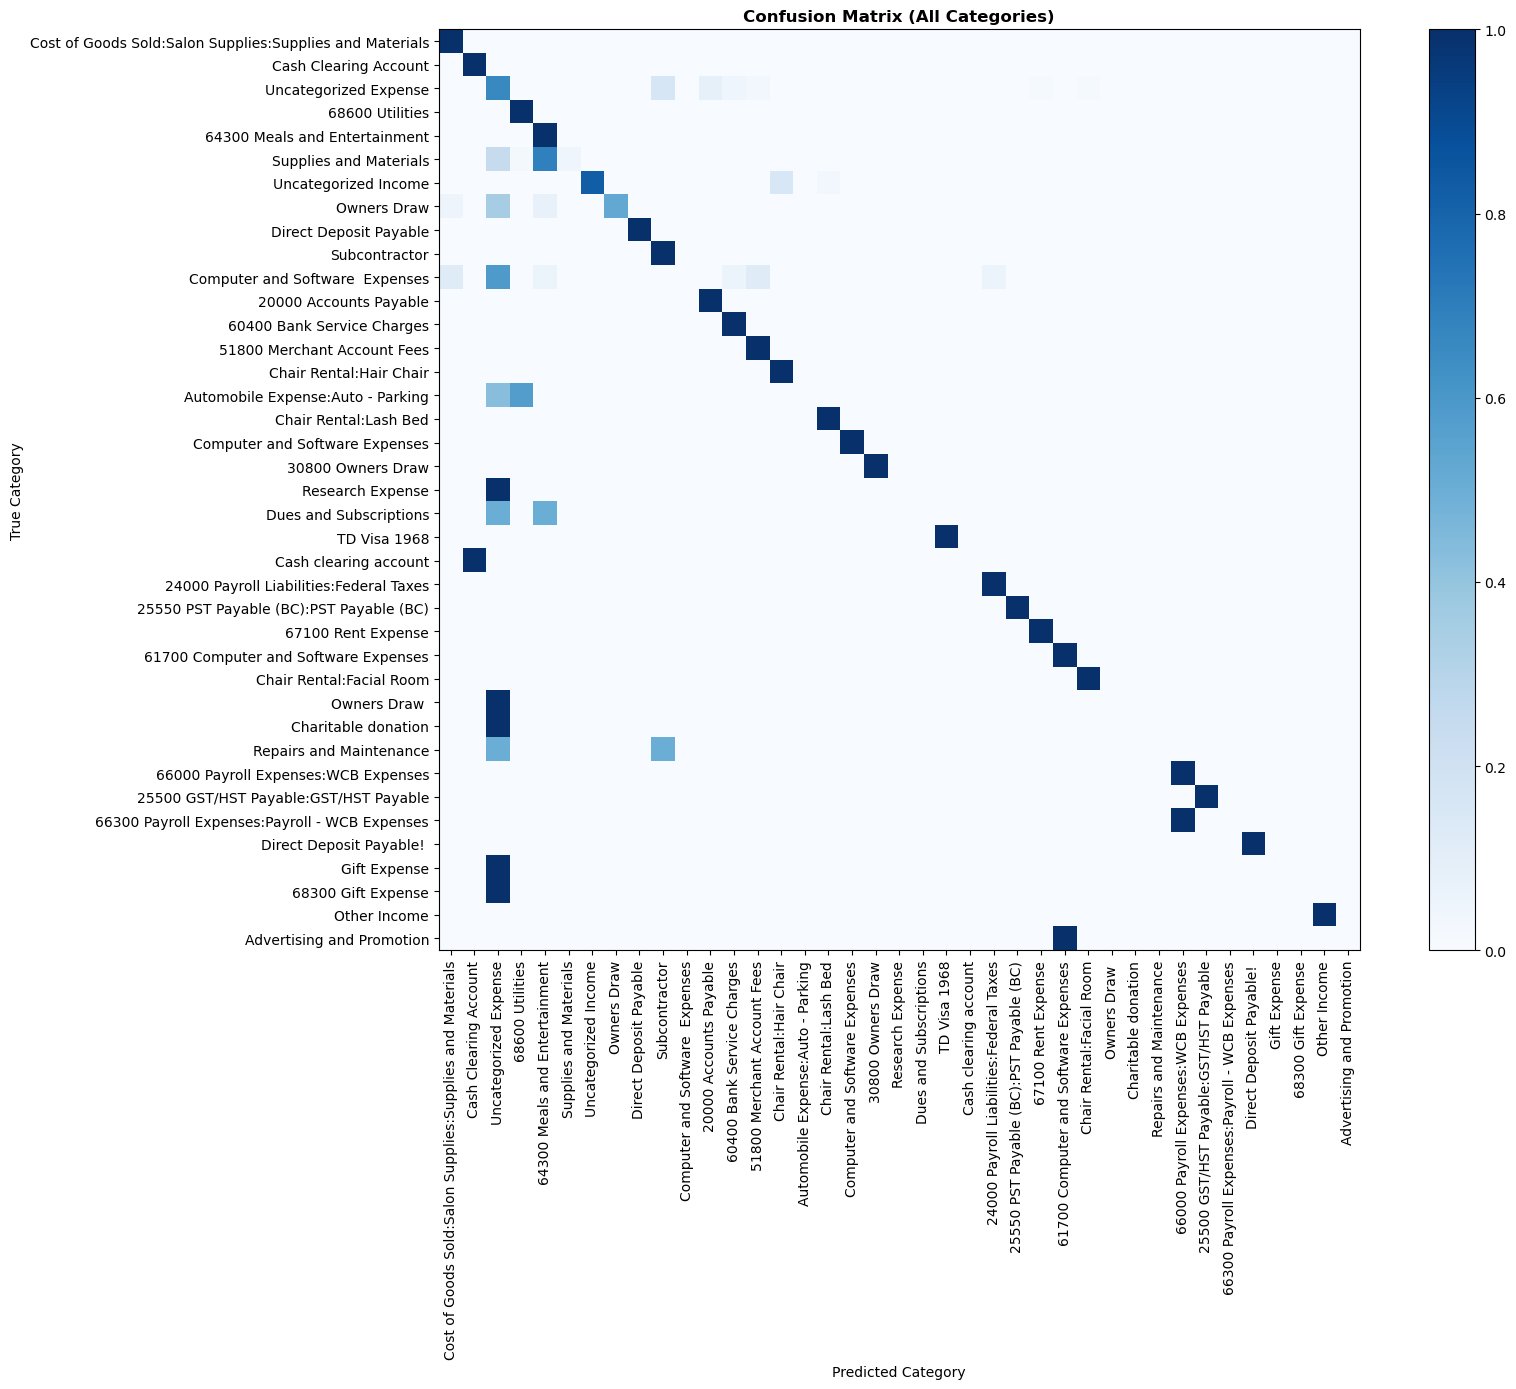

In [112]:

sorted_by_size = sorted(category_performance.items(), key=lambda x: x[1]['total'], reverse=True)
categories = [cat for cat, _ in sorted_by_size]  # full names
sizes = [perf['total'] for _, perf in sorted_by_size]
accuracies_top = [perf['accuracy'] for _, perf in sorted_by_size]
# Use all categories instead of top 10
all_categories = [cat for cat, _ in sorted_by_size]
cm = confusion_matrix(actuals, predictions, labels=all_categories)

# Normalize
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_normalized = np.nan_to_num(cm_normalized)

plt.figure(figsize=(18, 14))
im = plt.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix (All Categories)', fontweight='bold')

# Ticks
tick_marks = np.arange(len(all_categories))
plt.xticks(tick_marks, all_categories, rotation=90)
plt.yticks(tick_marks, all_categories)

# Colorbar
plt.colorbar(im)
plt.ylabel('True Category')
plt.xlabel('Predicted Category')
plt.tight_layout()
plt.show()


In [113]:
assigned_unique = set(df['AssignedCategory'].unique())
category_unique = set(df['Category'].unique())

# Take the union of both
all_unique = assigned_unique.union(category_unique)

print("Unique Assigned_Category:", assigned_unique)
print("Unique Category:", category_unique)
print("Union of both:", all_unique)

Unique Assigned_Category: {'Uncategorized Income', 'Other Income', 'Direct Deposit Payable! ', 'Undeposited Funds', '64300 Meals and Entertainment', '20000 Accounts Payable', 'Uncategorized Expense', '30800 Owners Draw', 'Direct Deposit Payable', 'Chair Rental:Hair Chair', 'Computer and Software Expenses', '67100 Rent Expense', '66000 Payroll Expenses:WCB Expenses', 'Cash Clearing Account', 'TD Visa 1968', '68600 Utilities', 'Owners Draw', '60400 Bank Service Charges', '51800 Merchant Account Fees', 'Chair Rental:Facial Room', '9', 'Supplies and Materials', '25550 PST Payable (BC):PST Payable (BC)', 'Chair Rental:Lash Bed', '25500 GST/HST Payable:GST/HST Payable', '24000 Payroll Liabilities:Federal Taxes', '61700 Computer and Software Expenses', 'Cost of Goods Sold:Salon Supplies:Supplies and Materials', 'Subcontractor'}
Unique Category: {'Computer and Software  Expenses', 'Gift Expense', 'Supplies and Materials', 'Automobile Expense:Auto - Parking', 'Uncategorized Income', 'Cash clear

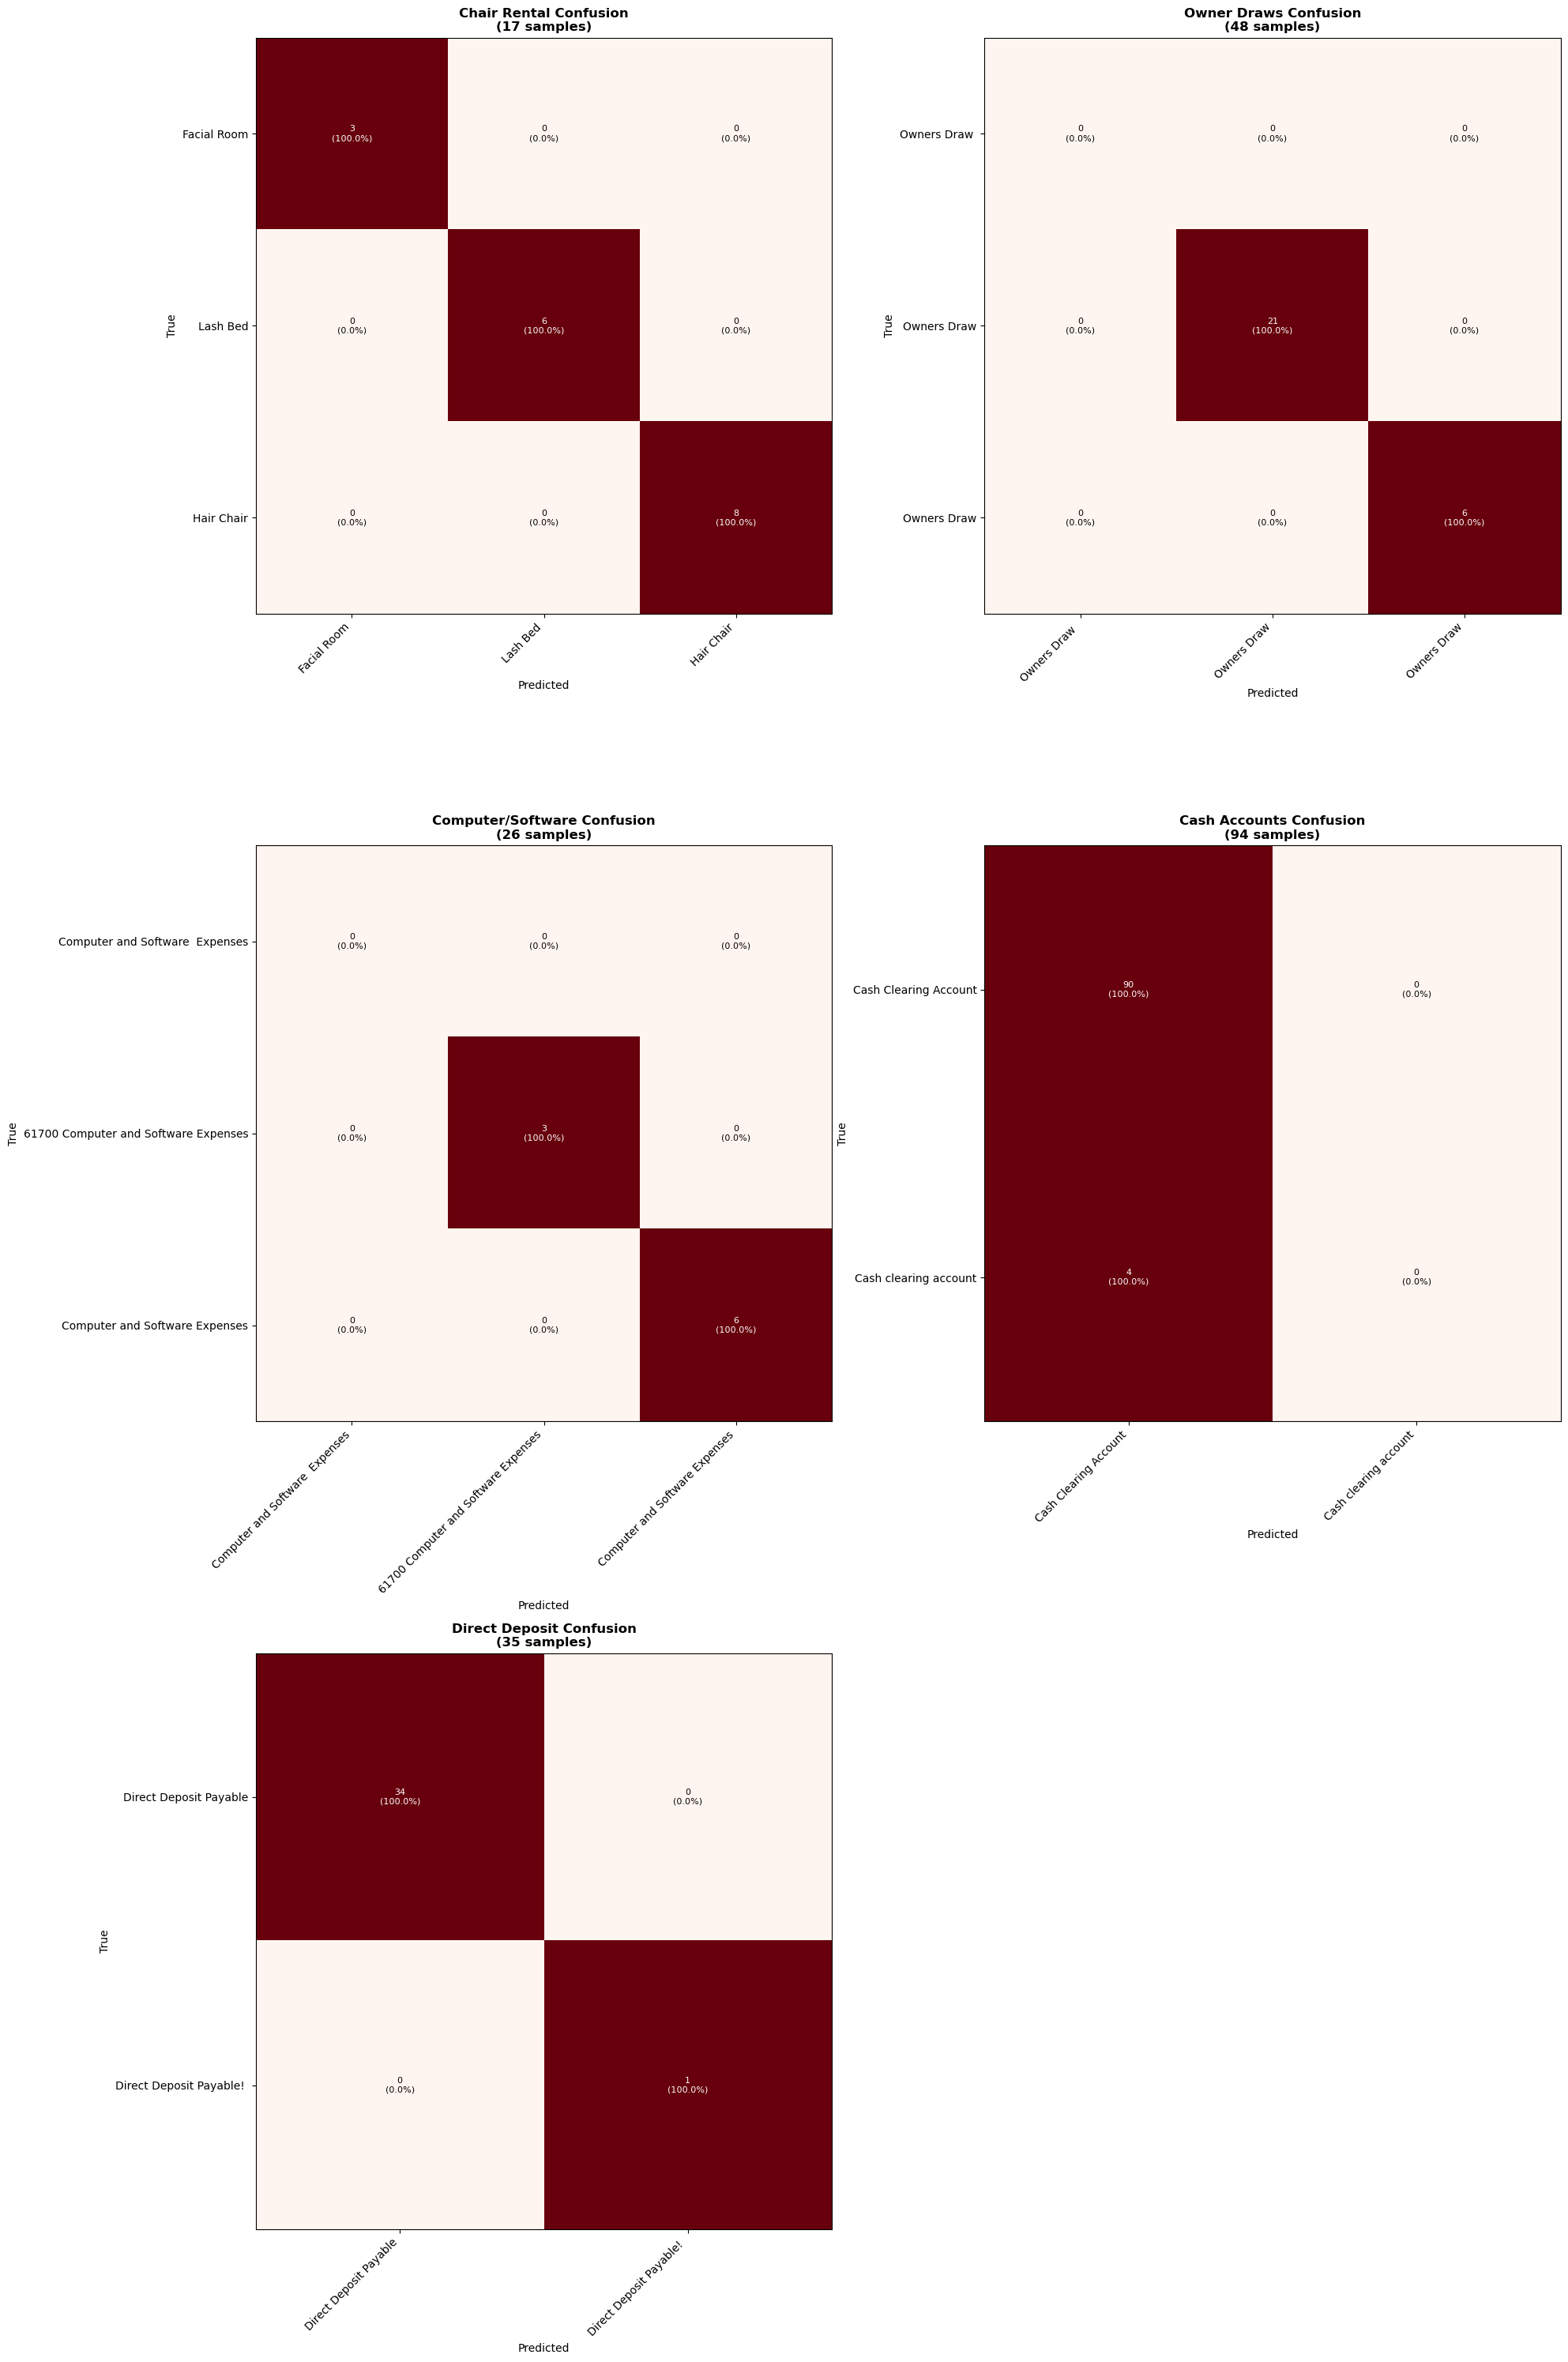

In [114]:
def create_similar_category_analysis(actuals, predictions):
    """Create detailed confusion analysis for similar categories"""
    
    # Here we define groups of similar categories
    # We can adjust these groups based on your domain knowledge or analysis
    similar_groups = {
        'Chair Rental': [
            'Chair Rental:Hair Chair',
            'Chair Rental:Lash Bed', 
            'Chair Rental:Facial Room'
        ],
        'Owner Draws': [
            'Owners Draw',
            'Owners Draw ',
            '30800 Owners Draw'
        ],
        'Computer/Software': [
            'Computer and Software Expenses',
            'Computer and Software  Expenses',
            '61700 Computer and Software Expenses'
        ],
        'Cash Accounts': [
            'Cash Clearing Account',
            'Cash clearing account'
        ],
        'Direct Deposit': [
            'Direct Deposit Payable',
            'Direct Deposit Payable! '
        ]
    }
    
    # Create visualizations for each group
    _, axes = plt.subplots(3, 2, figsize=(20, 30))
    
    axes = axes.flatten()
    
    for idx, (group_name, categories) in enumerate(similar_groups.items()):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        
        # Filter data for this group
        group_true = []
        group_pred = []
        
        for true_cat, pred_cat in zip(actuals, predictions):
            if true_cat in categories:
                group_true.append(true_cat)
                group_pred.append(pred_cat)
        
        if len(group_true) == 0:
            ax.text(0.5, 0.5, f'No data for\n{group_name}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{group_name} Confusion', fontweight='bold')
            continue
    
        
        # Get unique categories in this group that actually appear in data
        actual_categories = list(set(group_true + group_pred) & set(categories))
        
        if len(actual_categories) > 1:
            cm = confusion_matrix(group_true, group_pred, labels=actual_categories)
            
            # Normalize by row to show percentages
            cm_normalized = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-10)
            
            # Create heatmap
            im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Reds', vmin=0, vmax=1)
            
            # Add text annotations
            thresh = cm_normalized.max() / 2.
            for i in range(cm.shape[0]):
                for j in range(cm.shape[1]):
                    ax.text(j, i, f'{cm[i, j]}\n({cm_normalized[i, j]:.1%})',
                           ha="center", va="center",
                           color="white" if cm_normalized[i, j] > thresh else "black",
                           fontsize=8)
            
            # Set labels
            ax.set_xticks(range(len(actual_categories)))
            ax.set_yticks(range(len(actual_categories)))
            ax.set_xticklabels([cat.replace('Chair Rental:', '').replace('30800 ', '') 
                               for cat in actual_categories], rotation=45, ha='right')
            ax.set_yticklabels([cat.replace('Chair Rental:', '').replace('30800 ', '') 
                               for cat in actual_categories])
            
            ax.set_xlabel('Predicted')
            ax.set_ylabel('True')
            ax.set_title(f'{group_name} Confusion\n({len(group_true)} samples)', fontweight='bold')
            
        else:
            # Only one category in this group appears in data
            ax.text(0.5, 0.5, f'{group_name}\nOnly 1 category\nwith data', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(f'{group_name} Confusion', fontweight='bold')
    
    # Hide unused subplots
    for idx in range(len(similar_groups), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    return similar_groups

# Create the similar category analysis
similar_groups = create_similar_category_analysis(actuals, predictions)



In [115]:
print(f"\n📝 Category Name Standardization Issues:")
standardization_issues = {
    'Chair Rental': ['Chair Rental:Hair Chair', 'Chair Rental:Lash Bed', 'Chair Rental:Facial Room'],
    'Owners Draw': ['Owners Draw', 'Owners Draw ', '30800 Owners Draw'],
    'Computer Expenses': ['Computer and Software Expenses', 'Computer and Software  Expenses', '61700 Computer and Software Expenses'],
    'Cash Clearing': ['Cash Clearing Account', 'Cash clearing account'],
    'Direct Deposit': ['Direct Deposit Payable', 'Direct Deposit Payable! ']
}

for base_category, variations in standardization_issues.items():
    variation_counts = {}
    for var in variations:
        count_true = actuals.count(var)
        count_pred = predictions.count(var)
        if count_true > 0 or count_pred > 0:
            variation_counts[var] = {'true': count_true, 'pred': count_pred}
    
    if variation_counts:
        print(f"\n  {base_category} variations:")
        for var, counts in variation_counts.items():
            print(f"    '{var}': {counts['true']} true, {counts['pred']} predicted")




📝 Category Name Standardization Issues:

  Chair Rental variations:
    'Chair Rental:Hair Chair': 8 true, 14 predicted
    'Chair Rental:Lash Bed': 6 true, 7 predicted
    'Chair Rental:Facial Room': 3 true, 4 predicted

  Owners Draw variations:
    'Owners Draw': 40 true, 21 predicted
    'Owners Draw ': 2 true, 0 predicted
    '30800 Owners Draw': 6 true, 6 predicted

  Computer Expenses variations:
    'Computer and Software Expenses': 6 true, 6 predicted
    'Computer and Software  Expenses': 17 true, 0 predicted
    '61700 Computer and Software Expenses': 3 true, 4 predicted

  Cash Clearing variations:
    'Cash Clearing Account': 90 true, 94 predicted
    'Cash clearing account': 4 true, 0 predicted

  Direct Deposit variations:
    'Direct Deposit Payable': 34 true, 34 predicted
    'Direct Deposit Payable! ': 1 true, 1 predicted


In [116]:
print(f"\n Key Insights from Analysis:")
print(f"1. Overall system accuracy: {metrics['accuracy']:.1%}")
print(f"2. Number of unique categories: {len(category_performance)}")
print(f"3. Categories with perfect accuracy: {sum(1 for p in category_performance.values() if p['accuracy'] == 1.0)}")
print(f"4. Categories needing improvement: {sum(1 for p in category_performance.values() if p['accuracy'] < 0.8)}")

if errors:
    print(f"5. Most problematic category pairs (frequent misclassifications):")
    error_counts = Counter(errors)
    for (true_cat, pred_cat), count in error_counts.most_common(3):
        print(f"   • {true_cat} → {pred_cat} ({count} times)")




 Key Insights from Analysis:
1. Overall system accuracy: 81.7%
2. Number of unique categories: 39
3. Categories with perfect accuracy: 23
4. Categories needing improvement: 15
5. Most problematic category pairs (frequent misclassifications):
   • Supplies and Materials → 64300 Meals and Entertainment (31 times)
   • Owners Draw → Uncategorized Expense (14 times)
   • Uncategorized Expense → Subcontractor (11 times)


### 🔁 Task 2: Analyze Patterns of Misclassification

- Analyze patterns in transactions the AI got wrong.
- Do specific  names ,  paymentChannels , or  types  often lead to errors?
- Are certain categories underrepresented and thus harder for the AI to learn?

Deliverables may include:

- Sample rows with AI vs. human labels
- Short write-up explaining your insights

In [117]:
# TASK 2: ANALYZE PATTERNS OF MISCLASSIFICATION
def analyze_misclassification_patterns(df, actuals, predictions):
    
    analysis_df = df.copy()
    analysis_df['ground_truth'] = actuals
    analysis_df['ai_prediction'] = predictions
    analysis_df['is_correct'] = [t == p for t, p in zip(actuals, predictions)]
    analysis_df['is_error'] = ~analysis_df['is_correct']
    # print(analysis_df.head())
    
    # Get only the misclassified transactions
    errors_df = analysis_df[analysis_df['is_error']].copy()
    correct_df = analysis_df[analysis_df['is_correct']].copy()
    
    print(f"📊 Misclassification Overview:")
    print(f"Total transactions: {len(analysis_df)}")
    print(f"Correct predictions: {len(correct_df)} ({len(correct_df)/len(analysis_df)*100:.1f}%)")
    print(f"Incorrect predictions: {len(errors_df)} ({len(errors_df)/len(analysis_df)*100:.1f}%)")
    
    return analysis_df, errors_df, correct_df





In [130]:
# Perform the analysis
analysis_df, errors_df, correct_df = analyze_misclassification_patterns(df, actuals, predictions)

# Get 5 representative error samples
sample_errors = errors_df.sample(50, random_state=42)[[
    'name', 'amount', 'description', 'paymentChannel', 'type',
    'AssignedCategory', 'Category'
]]

print("\n🔍 Sample Misclassified Transactions:")
print(sample_errors.to_markdown(index=False))

📊 Misclassification Overview:
Total transactions: 776
Correct predictions: 634 (81.7%)
Incorrect predictions: 142 (18.3%)

🔍 Sample Misclassified Transactions:
| name                      |   amount | description               | paymentChannel   | type    | AssignedCategory                                         | Category                          |
|:--------------------------|---------:|:--------------------------|:-----------------|:--------|:---------------------------------------------------------|:----------------------------------|
| APPLE.COM/BILL            |   -27.99 | APPLE.COM/BILL            | online           | digital | 64300 Meals and Entertainment                            | Computer and Software  Expenses   |
| ARITZIA.COM               |   -42.56 | ARITZIA.COM               | online           | place   | Uncategorized Expense                                    | Owners Draw                       |
| Global-e.Sporty and       |  -820.32 | Global-e.Sporty and Ri    |

In [119]:
print(errors_df['name'].unique())


['SEND E-TFR ***Ygf' 'SEND E-TFR *YBZ AP' 'SEND E-TFR ***hPU'
 'SEND E-TFR *BMY AP' 'SEND E-TFR ***H6Y' 'SEND E-TFR FEE'
 'E-TRANSFER ***Bcu' 'SEND E-TFR ***EQ5' 'SEND E-TFR *DWw AP'
 'E-TRANSFER ***JgW' 'E-TRANSFER ***TRC' 'SEND E-TFR ***4TH'
 'E-TFR ***Jrj EPAY' 'E-TRANSFER ***ZNG' 'E-TFR ***kkB EPAY'
 'E-TRANSFER ***MTu'
 'View more E-TRANSFER ***CPm View more E-TRANSFER ***CPm'
 'APPLE.COM/BILL' 'ARITZIA.COM' 'SEND E-TFR *b57 AP' 'E-TRANSFER ***Kza'
 'SEND E-TFR ***hWD' 'SEND E-TFR ***Rwn' 'SEND E-TFR *MRE AP'
 'WORKERS COMP BC WCB' 'SEND E-TFR ***3yh' 'SEND E-TFR *cxM AP'
 'CC.CAREGUIDE.COM' 'TEMU.COM' 'CHQ#00064-4143922650'
 'Phorest Pay-Pho MSP' 'NANNYSERVICES.CA' 'CHOICES YALETOWN # 907'
 'SEND E-TFR *jEj AP' 'SEND E-TFR *mJ5 AP' 'Netflix' 'PHOREST'
 'SEND E-TFR ***nGt' 'Shoppers Drug Mart' 'Spotify' 'SP HEIRESS CLOTHING'
 'IN *LENSEN ENTERPRISES IN' 'Global-e.Sporty and' 'INTUIT *QBooks Online'
 "Carter\\'s" 'CITY OF VAN PAYBYPHONE' 'SP MYORGANICFORMULA.'
 'Uniqlo Canada POS_C

In [120]:
errors_df['name'].nunique()

64


- Do specific  names ,  paymentChannels , or  types  often lead to errors?



In [133]:
# 1. ANALYZE TRANSACTION NAME PATTERNS
print(f"\n🏷️ Transaction Name Pattern Analysis:")

def analyze_name_patterns(errors_df):
    # Extract name patterns for errors
    if len(errors_df) > 0:
        error_names = errors_df['name'].value_counts().head(15)
        print(f"\n❌ Most Common Transaction Names in Errors.(Here I took only top 15 transaction):")
        for name, count in error_names.items():
            total_with_name = len(df[df['name'] == name])
            error_rate = count / total_with_name if total_with_name > 0 else 0
            print(f"  '{name}': {count} errors out of {total_with_name} total ({error_rate:.1%} error rate)")
        
        # Analyze name patterns (E-TRANSFER, SEND E-TFR, etc.)
        error_name_patterns = {}
        for name in errors_df['name'].fillna(''):
            # Extract patterns
            if 'E-TRANSFER' in str(name).upper():
                pattern = 'E-TRANSFER'
            elif 'SEND E-TFR' in str(name).upper():
                pattern = 'SEND E-TFR'
            elif 'PAYROLL' in str(name).upper():
                pattern = 'PAYROLL'
            elif 'CHQ#' in str(name).upper():
                pattern = 'CHECK'
            else:
                pattern = 'OTHER'
            
            error_name_patterns[pattern] = error_name_patterns.get(pattern, 0) + 1
        
        print(f"\n📈 Error Patterns by Transaction Type:")
        total_errors = sum(error_name_patterns.values())
        for pattern, count in sorted(error_name_patterns.items(), key=lambda x: x[1], reverse=True):
            print(f"  {pattern}: {count} errors ({count/total_errors*100:.1f}% of errors)")
    
    return error_name_patterns if len(errors_df) > 0 else {}

error_name_patterns = analyze_name_patterns(errors_df)


🏷️ Transaction Name Pattern Analysis:

❌ Most Common Transaction Names in Errors.(Here I took only top 15 transaction):
  'CHOICES YALETOWN # 907': 28 errors out of 87 total (32.2% error rate)
  'NANNYSERVICES.CA': 10 errors out of 34 total (29.4% error rate)
  'APPLE.COM/BILL': 9 errors out of 16 total (56.2% error rate)
  'CITY OF VAN PAYBYPHONE': 7 errors out of 47 total (14.9% error rate)
  'TEMU.COM': 6 errors out of 14 total (42.9% error rate)
  'CC.CAREGUIDE.COM': 5 errors out of 11 total (45.5% error rate)
  'Netflix': 5 errors out of 9 total (55.6% error rate)
  'SEND E-TFR FEE': 5 errors out of 12 total (41.7% error rate)
  'Phorest Pay-Pho MSP': 4 errors out of 91 total (4.4% error rate)
  'PHOREST': 4 errors out of 9 total (44.4% error rate)
  'ARITZIA.COM': 2 errors out of 4 total (50.0% error rate)
  'Spotify': 2 errors out of 7 total (28.6% error rate)
  'LS THE CROSS DECOR AND': 2 errors out of 2 total (100.0% error rate)
  'BROWNSSHOES.COM': 2 errors out of 2 total (1

In [122]:
analysis_df['paymentChannel'].unique()

array(['other', 'online', 'in store'], dtype=object)

In [134]:
# 2. ANALYZE PAYMENT CHANNEL PATTERNS
print(f"\n💳 Payment Channel Analysis:")

def analyze_payment_channel_patterns(analysis_df):
    channel_stats = {}
    for channel in analysis_df['paymentChannel'].unique():
        if pd.isna(channel):
            channel = 'Unknown'
        
        channel_data = analysis_df[analysis_df['paymentChannel'] == channel]
        total = len(channel_data)
        errors = len(channel_data[channel_data['is_error']])
        error_rate = errors / total if total > 0 else 0
        
        channel_stats[channel] = {
            'total': total,
            'errors': errors,
            'error_rate': error_rate
        }
    
    print(f"\n📊 Error Rates by Payment Channel:")
    for channel, stats in sorted(channel_stats.items(), key=lambda x: x[1]['error_rate'], reverse=True):
        print(f"  {channel}: {stats['error_rate']:.1%} error rate ({stats['errors']}/{stats['total']})")
    
    return channel_stats

channel_stats = analyze_payment_channel_patterns(analysis_df)




💳 Payment Channel Analysis:

📊 Error Rates by Payment Channel:
  online: 27.2% error rate (40/147)
  other: 16.5% error rate (43/260)
  in store: 16.0% error rate (59/369)


In [124]:
# 3. ANALYZE TRANSACTION TYPE PATTERNS
print(f"\n🔍 Transaction Type Analysis:")

def analyze_type_patterns(analysis_df):
    type_stats = {}
    for trans_type in analysis_df['type'].unique():
        if pd.isna(trans_type):
            trans_type = 'Unknown'
        
        type_data = analysis_df[analysis_df['type'] == trans_type]
        total = len(type_data)
        errors = len(type_data[type_data['is_error']])
        error_rate = errors / total if total > 0 else 0
        
        type_stats[trans_type] = {
            'total': total,
            'errors': errors,
            'error_rate': error_rate
        }
    
    print(f"\n📊 Error Rates by Transaction Type:")
    for trans_type, stats in sorted(type_stats.items(), key=lambda x: x[1]['error_rate'], reverse=True):
        print(f"  {trans_type}: {stats['error_rate']:.1%} error rate ({stats['errors']}/{stats['total']})")
    
    return type_stats

type_stats = analyze_type_patterns(analysis_df)




🔍 Transaction Type Analysis:

📊 Error Rates by Transaction Type:
  digital: 26.3% error rate (10/38)
  place: 20.9% error rate (90/430)
  special: 13.6% error rate (42/308)



- Are certain categories underrepresented and thus harder for the AI to learn?


In [125]:
# 5. ANALYZE CATEGORY REPRESENTATION
print(f"\n📚 Category Representation Analysis:")

def analyze_category_representation(analysis_df):
    category_representation = {}
    
    for category in analysis_df['ground_truth'].unique():
        cat_data = analysis_df[analysis_df['ground_truth'] == category]
        total = len(cat_data)
        errors = len(cat_data[cat_data['is_error']])
        error_rate = errors / total if total > 0 else 0
        
        # Categorize representation level
        if total >= 20:
            representation_level = 'Well Represented (≥20)'
        elif total >= 10:
            representation_level = 'Moderately Represented (10-19)'
        elif total >= 5:
            representation_level = 'Underrepresented (5-9)'
        else:
            representation_level = 'Severely Underrepresented (<5)'
        
        category_representation[category] = {
            'total': total,
            'errors': errors,
            'error_rate': error_rate,
            'representation_level': representation_level
        }
    
    # Group by representation level
    representation_levels = {}
    for cat, stats in category_representation.items():
        level = stats['representation_level']
        if level not in representation_levels:
            representation_levels[level] = {'categories': 0, 'total_samples': 0, 'total_errors': 0, 'category_names': []}
        
        representation_levels[level]['categories'] += 1
        representation_levels[level]['total_samples'] += stats['total']
        representation_levels[level]['total_errors'] += stats['errors']
        representation_levels[level]['category_names'].append(cat)
    
    print(f"\n📊 Error Rates by Category Representation Level:")
    for level, stats in representation_levels.items():
        avg_error_rate = stats['total_errors'] / stats['total_samples'] if stats['total_samples'] > 0 else 0
        print(f"  {level}:")
        print(f"    Categories: {stats['categories']}")
        print(f"    Average Error Rate: {avg_error_rate:.1%}")
        print(f"    Total Samples: {stats['total_samples']}")
        print(f"    Category Names: {', '.join(stats['category_names'])}")
    
    
    
    return category_representation, representation_levels

category_representation, representation_levels = analyze_category_representation(analysis_df)



📚 Category Representation Analysis:

📊 Error Rates by Category Representation Level:
  Underrepresented (5-9):
    Categories: 7
    Average Error Rate: 39.5%
    Total Samples: 43
    Category Names: Chair Rental:Hair Chair, Chair Rental:Lash Bed, Computer and Software Expenses, 30800 Owners Draw, Research Expense, Dues and Subscriptions, Automobile Expense:Auto - Parking
  Well Represented (≥20):
    Categories: 9
    Average Error Rate: 15.2%
    Total Samples: 620
    Category Names: Direct Deposit Payable, Uncategorized Income, Cash Clearing Account, Cost of Goods Sold:Salon Supplies:Supplies and Materials, 68600 Utilities, Owners Draw, Uncategorized Expense, 64300 Meals and Entertainment, Supplies and Materials
  Moderately Represented (10-19):
    Categories: 5
    Average Error Rate: 22.4%
    Total Samples: 76
    Category Names: 60400 Bank Service Charges, 51800 Merchant Account Fees, 20000 Accounts Payable, Subcontractor, Computer and Software  Expenses
  Severely Underrepr

In [126]:
def print_under_representation_with_error(category_representation, min_samples, min_error_rate, high_low):
    if high_low == 'Low':
        represented = {cat: stats for cat, stats in category_representation.items() 
                            if stats['total'] < min_samples and stats['error_rate'] < min_error_rate}
    else:
        represented = {cat: stats for cat, stats in category_representation.items() 
                            if stats['total'] < min_samples and stats['error_rate'] >= min_error_rate}

    if represented:
        print(f"\n⚠️ Underrepresented Categories with {high_low} Error Rates:")
        sorted_under = sorted(represented.items(), key=lambda x: x[1]['error_rate'], reverse=True)
        for category, stats in sorted_under:
            print(f"  {category}: {stats['error_rate']:.1%} error rate ({stats['errors']}/{stats['total']} samples)")
            
            
def print_well_representation_with_error(category_representation, min_samples, min_error_rate, high_low):
    if high_low == 'Low':
        represented = {cat: stats for cat, stats in category_representation.items() 
                            if stats['total'] >= min_samples and stats['error_rate'] < min_error_rate}
    else:
        represented = {cat: stats for cat, stats in category_representation.items() 
                            if stats['total'] >= min_samples and stats['error_rate'] >= min_error_rate}

    if represented:
        print(f"\n⚠️ Well represented Categories with {high_low} Error Rates:")
        sorted_under = sorted(represented.items(), key=lambda x: x[1]['error_rate'], reverse=True)
        for category, stats in sorted_under:
            print(f"  {category}: {stats['error_rate']:.1%} error rate ({stats['errors']}/{stats['total']} samples)")
            



In [127]:
print_under_representation_with_error(category_representation, 20, 0.5, "High")
print_under_representation_with_error(category_representation, 20, 0.5, "Low")
print_well_representation_with_error(category_representation, 20, 0.5, "High")
print_well_representation_with_error(category_representation, 20, 0.5, "Low")


⚠️ Underrepresented Categories with High Error Rates:
  Computer and Software  Expenses: 100.0% error rate (17/17 samples)
  Owners Draw : 100.0% error rate (2/2 samples)
  66300 Payroll Expenses:Payroll - WCB Expenses: 100.0% error rate (1/1 samples)
  Research Expense: 100.0% error rate (5/5 samples)
  Cash clearing account: 100.0% error rate (4/4 samples)
  Dues and Subscriptions: 100.0% error rate (5/5 samples)
  Automobile Expense:Auto - Parking: 100.0% error rate (7/7 samples)
  Charitable donation: 100.0% error rate (2/2 samples)
  Gift Expense: 100.0% error rate (1/1 samples)
  68300 Gift Expense: 100.0% error rate (1/1 samples)
  Repairs and Maintenance: 100.0% error rate (2/2 samples)
  Advertising and Promotion: 100.0% error rate (1/1 samples)

⚠️ Underrepresented Categories with Low Error Rates:
  Chair Rental:Hair Chair: 0.0% error rate (0/8 samples)
  Chair Rental:Lash Bed: 0.0% error rate (0/6 samples)
  Computer and Software Expenses: 0.0% error rate (0/6 samples)
  60

### Short write-up

The AI correctly categorized 82% of transactions (634/776) but made repeated mistakes on a focused set of names, online/digital payments, and categories with few examples. Many errors come from ambiguous or masked merchant strings like View more E-TFR ,6DE EPAY View more E-TFR ,6DE EPAY, APPLE.COM/BILL, Netflix. and from inconsistent category labels. Fixing a relatively small number of vendor mappings, label canonicalization, and a few deterministic rules should cut a large share of errors quickly.

**Key findings**
* Overall accuracy: 81.7%; error rate 18.3% (142/776).
* Errors concentrate on a small set of merchant names like CHOICES YALETOWN, NANNYSERVICES.CA, APPLE.COM/BILL, TEMU, Netflix.
* online and digital transactions have the highest error rates like online ≈ 27%; digital ≈ 26%.
* Underrepresented categories (few examples) show much higher error rates (often >30–40%); some tiny classes had 100% errors.
* Frequent misclassifications include supply ↔ meals confusions and many fallbacks to Uncategorized Expense.

**Root causes**

* Masked or terse descriptions provide little vendor context (E-TRANSFERS, masked tokens).
* Category name variants (spacing, punctuation, numeric prefixes) fragment labels and confuse scoring/model behavior.
* The model lacks targeted examples/rules for ambiguous online marketplace or subscription vendors.
* Small-sample categories don’t have enough examples for reliable learning.

**Concrete, high-impact fixes**

1. **Canonicalize category labels** (map all variants to a single canonical label).
2. **Normalize merchant text** (uppercase, remove punctuation, extract tokens) before classification.
3. **Create a vendor→category lookup** for top \~30–50 error-prone merchants (apply as a high-priority rule).
4. **Add deterministic rules** for obvious patterns (e.g., GST* → GST payable; SEND E-TFR *... AP → Accounts Payable; PHOREST → Cash Clearing).
5. **Require structured JSON output** including confidence so low-confidence cases can be routed to humans.

### Which categories to focus on (ranked)

1. **Supplies and Materials** (Cononical Issue)
2. **Computer and Software Expenses** (Cononical Issue)
3. **Owner’s Draw** (Cononical Issue)
4. **Uncategorized Expense / Uncategorized Income** (Model confuse)
5. **Cash Clearing Account** (Cononical Issue)
6. **Underrepresented 100%-error categories** (collect examples; medium priority):
   * Research Expense, Dues and Subscriptions, Automobile Expense — Parking, Charitable donation, Gift Expense, Repairs and Maintenance, Advertising & Promotion, Payroll/WCB variants







### 📐 Optional Task 3: Suggest Evaluation Metrics or Pipelines

- Propose how this categorization system could be **evaluated regularly** in production
- Design a minimal evaluation pipeline (describe it, or code it if you prefer) that uses incoming bookkeeper feedback to:
    - Detect performance drift
    - Flag uncertain predictions for human review
    - Incorporate human corrections for retraining

📎 *Bonus*: Suggest how to use the  ConfidenceScore  to guide fallback logic

Keep the **prompt** as the first line of defense: track predictions + human corrections, compute prompt-aware metrics hourly/daily, route uncertain or suspicious items to humans, auto-suggest prompt edits (vendor lookup, few-shots, rules), and only retrain the model when prompt fixes don’t close the gap.

### Pipeline (hourly / daily)

1. **Ingest predictions**
   * Store: Explanation, transactionId, AssignedCategory, ConfidenceScore, AccountNumber, TypeOfTransaction, Payee, Taxes, normalized_name, system_prompt_snapshot, few_shots_examples_used.

2. **Ingest human feedback**
   * Store correction, Type of Transaction, Payee/Vendor, Account Number, Tax and short reason_tag by looking at Ai generated description.(The reason should tells us either the error occurs because of vendor, wrong few shot example)
   * Use reason_tag to decide: (a) vendor lookup, (b) few-shot example, (c) deterministic rule.

3. **Daily evaluation job**
   * Join predictions + corrections.
   * Compute metrics.
   * Prompt-specific checks: which few-shots matched, which lookup keys fired, which rules fired, and which mistakes would’ve been fixed by a hypothetical rule.
   * Evaluator & Prompt Generation Agent: Ingests predictions, human corrections, ai_explanation, and human_explanation to evaluate prompt health, identify top failing vendor tokens, propose few-shot/lookup/rule updates, and generate a corrected prompt version.
   * Categorization Agent: Uses the updated prompt to categorize incoming transactions.

4. **Human-review queue**
   * Queue items include the exact prompt context (system prompt snapshot, few-shots used, vendor lookup snippet) + model analysis.
   * Selection policy: low confidence (<0.6) + sample of medium (0.6–0.8) + recent high-confidence errors.

5. **Feedback absorption (prompt-first rules)**
   * If corrected vendor occurs ≥N times in last 7 days → auto-add to vendor lookup table.(the system will first look at lookup table if particular vendor appears in table, it directly assigned the relevant category to it.)
   * If corrected example resolves a confusing pair → add as few-shot examples.
   * If M corrections indicate a regex pattern → add deterministic rule into prompt.

6. **Deploy & monitor prompt changes**
   * Shadow-run updated prompt for 24–72 hrs against live traffic.
   * Promote prompt_version only when prompt-health metrics improve; otherwise rollback.

7. **Retrain policy**
   * Prefer prompt & lookup updates first.
   * Retrain only when prompt fixes don’t close the gap AND retrain triggers met (e.g., N verified corrections or schedule-based).

### Key metrics & alert thresholds (prompt-aware)

* **Prompt accuracy** — alert if drop > **3 percentage points**.
* **Prompt macro F1** — alert if decrease > **5%**.
* **Bookkeeper correction rate** = corrections / predictions. Target 12–15%. Alert if +5% absolute.
* **High-confidence error rate** (confidence ≥ 0.80) — alert if > **2%**.
* **Confidence calibration** by bin (expect monotonic accuracy).
* **Top-K confusion pairs** — detect rising trends → add few-shot/rule.
* **Prompt trigger coverage**: percent resolved by vendor lookup or deterministic rules.


**Fallback Logic Based on ConfidenceScore**

1. **High Confidence (≥ 0.80)** – **Auto-apply category**
   * No further processing needed.
   * Store prediction directly in the bookkeeping system.
   * Mark needs_review = false.

2. **Medium Confidence (0.60–0.79)** – **Take Sample for human feedback**
   * We can take samples of those confidence categories and give human feedback.
   * Then we use human feedback to decide weather we have to update confidence threshold or not.

3. **Low Confidence (< 0.60)** – **Human-in-the-loop review**
   * Immediately send to bookkeeper for manual category selection.
   * Include suggestion_for_human from the model to help them decide.



### Python pseudocode for above mentioned pipeline


```   python
# pseudocode - fill in your LLM client & storage
from typing import Dict, Any
import time

# === CONFIG ===
CONF_THRESH_AUTO = 0.80   # auto-apply
CONF_THRESH_HUMAN = 0.60  # human review sample

def pre_check_vendor(normalized_name: str, vendor_lookup: Dict[str, str]) -> str | None:
    """Check if vendor is in lookup table (first line of defense)."""
    return vendor_lookup.get(normalized_name)

def apply_deterministic_rules(transaction: Dict) -> str | None:
    """Apply known rules before calling LLM."""
    desc = transaction.get("description", "").upper()
    if "GST" in desc:
        return "25500 GST/HST Payable:GST/HST Payable"
    if "SEND E-TFR" in desc and "AP" in desc:
        return "20000 Accounts Payable"
    if "PHOREST" in desc:
        return "Cash Clearing Account"
    return None

def compute_confidence(pred_flags: Dict) -> float:
    """
    Confidence scoring:
    - Vendor lookup match → set 0.9 (authoritative)
    - Rule match +0.3
    - Amount sign agrees +0.2
    - Channel agrees +0.2
    - Keyword match +0.2
    - Masked vendor -0.3
    Max 1.0
    """
    if pred_flags.get("lookup_match"):
        return 0.9

    score = 0.0
    if pred_flags.get("rule_match"): score += 0.3
    if pred_flags.get("amount_sign_agrees"): score += 0.2
    if pred_flags.get("channel_agrees"): score += 0.2
    if pred_flags.get("keyword_match"): score += 0.2
    if pred_flags.get("masked_vendor"): score -= 0.3
    return max(0.0, min(1.0, score))

def call_llm(prompt_context: str, few_shots: list, snippet: str, transaction: Dict) -> Dict:
    """Call LLM with system prompt, few-shot examples, and lookup snippet."""
    return llm_client.predict(
        system_prompt=prompt_context,
        few_shots=few_shots,
        vendor_snippet=snippet,
        transaction=transaction
    )

def handle_prediction(transaction: Dict) -> Dict:
    """Main categorization pipeline for a single transaction."""
    vendor_key = pre_check_vendor(transaction["normalized_name"], vendor_lookup_full)
    log_meta = {
        "transactionId": transaction["transactionId"],
        "timestamp": transaction["timestamp"],
        "normalized_name": transaction["normalized_name"],
        "system_prompt_version": active_prompt_version,
    }

    # === 1. Vendor lookup short-circuit ===
    if vendor_key:
        out = {
            "transactionId": transaction["transactionId"],
            "category": vendor_key,
            "confidence": 0.95,
            "source": "lookup",
            "system_prompt_snapshot": system_prompt_text,
            "few_shots_examples_used": [],
            "needs_review": False
        }
        store_prediction(out, log_meta)
        return out

    # === 2. Deterministic rules ===
    rule_category = apply_deterministic_rules(transaction)
    flags = {
        "lookup_match": False,
        "rule_match": bool(rule_category),
        "amount_sign_agrees": transaction.get("amount", 0) < 0,
        "channel_agrees": transaction.get("paymentChannel") in ["in store", "card"],
        "keyword_match": contains_keywords(transaction.get("description", "")),
        "masked_vendor": is_masked(transaction["normalized_name"]),
    }

    # === 3. LLM prediction if rules fail ===
    predicted_category = rule_category
    llm_resp = {}
    if not predicted_category:
        snippet = make_lookup_snippet(transaction["normalized_name"], top_n=30)
        few_shots = get_rotating_few_shots()
        llm_resp = call_llm(system_prompt_text, few_shots, snippet, transaction)
        predicted_category = llm_resp.get("category")

    # === 4. Confidence calculation ===
    conf_score = compute_confidence(flags)

    # === 5. Build output object ===
    resp = {
        "transactionId": transaction["transactionId"],
        "category": predicted_category,
        "confidence": conf_score,
        "analysis": llm_resp.get("analysis", ""),
        "relevant_fields": llm_resp.get("relevant_fields", {}),
        "suggestion_for_human": llm_resp.get("suggestion_for_human", ""),
        "system_prompt_snapshot": system_prompt_text,
        "few_shots_examples_used": llm_resp.get("few_shots_examples_used", []),
    }

    # === 6. Fallback logic routing ===
    if conf_score >= CONF_THRESH_AUTO:
        resp["needs_review"] = False
    elif conf_score >= CONF_THRESH_HUMAN:
        resp["needs_review"] = "sample"
    else:
        resp["needs_review"] = True

    store_prediction(resp, log_meta)
    return resp

# === Hot-swap / feedback absorption ===
def hot_swap_vendor_lookup():
    candidates = find_candidate_vendor_additions(N=3)
    for key in candidates:
        create_vendor_lookup_version(add=key)
        run_shadow_on_backfill(duration_hours=24)
        if prompt_health_improves():
            promote_lookup_version()
        else:
            rollback_lookup_version()

```
   



### 🧪 Optional Task 4: Feedback Loop Design for Prompt Improvement

- Based on your findings, suggest how the existing prompt (provided separately) might be refined.
- Identify weaknesses in prompt examples or structure
- Propose new example transactions that could strengthen the prompt

📎 *Bonus*: Suggest how a few-shot LLM approach could help over prompt-only logic

**A: Prompt Refinement**

1. Enforce strict JSON schema.
2. Use exact canonical category list.
3. Pre-normalize inputs; pass normalized_name.
4. Vendor lookup first; skip LLM if match found.
5. Apply deterministic rules pre/within prompt.
6. Instruct model to compute & return confidence + brief analysis.
7. Include targeted few-shots (positive & negative).
8. Swap few-shots from recent corrections.

### We can use below system prompt


```   text
You are an expert bookkeeper. Use the canonical category list provided.

Categories:"Direct Deposit Payable, Chair Rental - Facial Room, Chair Rental - Hair Chair, Bank Service Charges, Cash Clearing Account, Chair Rental - Lash Bed, Rent Expense, Salon Supplies - Supplies and Materials, Utilities, Merchant Account Fees, Uncategorized Expense, Accounts Payable, Payroll Liabilities - Federal Taxes, PST Payable (BC), TD Visa 1968, Uncategorized Income, GST/HST Payable, Payroll Expenses - WCB Expenses, Meals and Entertainment, Subcontractor, Sales of Product Income, Furniture and Equipment, Other Income, Computer and Software Expenses, Sales, Owner's Draw, Commission, Professional Fees - Accounting, Rent Security Deposit, Undeposited Funds, MyJobs Test, Bank Loans"


The transaction details provided with these features name, amount, description, paymenChannel, and type.

FIRST: check vendor_lookup (version: VERSION) outside the LLM. If lookup matches, return that category with confidence 0.95 and "source":"lookup".

ELSE: apply deterministic rules (Examples rules: GST->tax; SEND E-TFR .* AP -> Accounts Payable; PHOREST->Cash Clearing).

if above both does not work. The use llm to predict the category. By genreating patterns from few shots examples.

THEN: produce a single JSON objectoutput (NO extra text) following this schema exactly:

{
  "transactionId": "",
  "category": "<canonical>",
  "confidence": 0.0,
  "analysis": "<one-line reason>",
  "relevant_fields": {
    "payee_matches": [],
    "amount_sign": "",
    "paymentChannel": "",
    "type": ""
  },
  "suggestion_for_human": "",
  "system_prompt_snapshot": "<full prompt or important excerpt used for this prediction>",
  "few_shots_examples_used": ["<example 1>", "<example 2>", "<example 3>"]
}


Compute numeric confidence [0.0–1.0]:
1) Short-circuits (strong signals):
   - If vendor token exactly in vendor_lookup → set confidence = 0.90, set "source":"lookup", and SKIP other rules.
2) Otherwise (no short-circuit), start at 0.0 and add:
   - +0.3 if deterministic rules matched
   - +0.2 if amount sign supports the category (negative → expense).
   - +0.2 if paymentChannel/type supports the category (e.g., "in store" for retail).
   - +0.2 if description or memo contains strong keywords.
3) Cap at 1.0. If vendor is masked (e.g., "E-TRANSFER ***"), subtract 0.3.
Return confidence as a float in JSON. Thresholds: ≥0.80 auto-apply; <0.60 human review.


ALSO: include  WHY  (one-line) and  CONFIDENCE_CALC  (which checks matched) in your JSON so feedback can be linked to prompt elements.

Few Shots examples: ....

```
   



### B: Concrete weaknesses in the current prompt & examples

* **Unenforced output format** : examples are XML-like; the prompt does not force JSON. This makes parsing fragile.
* **Example set is repetitive and skewed** : too many E-TRANSFE positive examples and not enough ambiguous or counterexamples (e.g., Apple.com sometimes software, sometimes refunded).
* **Category label variants present** : the prompt list contains inconsistent spacing and near-duplicates. This fragments training/evaluation.
* **No explicit confidence instructions** : ConfidenceScore exists downstream but the prompt never instructs how to compute or calibrate it.
* **No vendor lookup mention** : frequent vendors (Phorest, Apple, Netflix) should be resolved by lookup, but prompt lacks a mechanism to do so.
* **Missing use of numeric cues (amount sign/magnitude)** : prompts do not instruct how to use sign/amount thresholds for disambiguation.
* **No post-prediction action guidance** : which categories should be auto-applied vs human-reviewed is not in the prompt.


### C: New few-shot examples (copy-paste JSON-style for prompt)

These are the some few shots examples. These examples the pipeline we design above. I covers most frequent confusion that I learn during my analysis like subscriptions vs software, supplies vs meals, masked transfers, AP tokens, Phorest payouts, GST tokens, owner draw, and high-confidence rule cases.

Here is the conocical categories: Direct Deposit Payable, Chair Rental - Facial Room, Chair Rental - Hair Chair, Bank Service Charges, Cash Clearing Account, Chair Rental - Lash Bed, Rent Expense, Salon Supplies - Supplies and Materials, Utilities, Merchant Account Fees, Uncategorized Expense, Accounts Payable, Payroll Liabilities - Federal Taxes, PST Payable (BC), TD Visa 1968, Uncategorized Income, GST/HST Payable, Payroll Expenses - WCB Expenses, Meals and Entertainment, Subcontractor, Sales of Product Income, Furniture and Equipment, Other Income, Computer and Software Expenses, Sales, Owner's Draw, Commission, Professional Fees - Accounting, Rent Security Deposit, Undeposited Funds, MyJobs Test, Bank Loans


```json
[
  {
    "transactionId": "EX-001",
    "name": "PHOREST PAY MSP",
    "amount": 1221.03,
    "description": "Phorest Pay      MSP",
    "paymentChannel": "other",
    "type": "special",
    "category": "Cash Clearing Account",
    "confidence": 0.95,
    "analysis": "PHOREST token + positive amount -> clearing",
    "relevant_fields": {"payee_matches":["PHOREST","PHOREST PAY"], "amount_sign":"positive", "paymentChannel":"other", "type":"special"},
    "source": "lookup"
  },
  {
    "transactionId": "EX-002",
    "name": "APPLE.COM/BILL",
    "amount": -27.99,
    "description": "APPLE.COM/BILL",
    "paymentChannel": "online",
    "type": "digital",
    "category": "Computer and Software Expenses",
    "confidence": 0.88,
    "analysis": "APPLE.COM/BILL + subscription-like -> software expense",
    "relevant_fields": {"payee_matches":["APPLE.COM/BILL"], "amount_sign":"negative", "paymentChannel":"online", "type":"digital"},
    "source": "model_auto"
  },
  {
    "transactionId": "EX-003",
    "name": "NANNYSERVICES.CA",
    "amount": -48.00,
    "description": "NANNYSERVICES.CA",
    "paymentChannel": "online",
    "type": "place",
    "category": "Owner's Draw",
    "confidence": 0.90,
    "analysis": "Personal service vendor -> Owner's Draw",
    "relevant_fields": {"payee_matches":["NANNYSERVICES.CA"], "amount_sign":"negative", "paymentChannel":"online", "type":"place"},
    "source": "model_auto"
  },
  {
    "transactionId": "EX-004",
    "name": "GST-P 339306 BUS",
    "amount": -7730.06,
    "description": "GST-P  339306    BUS",
    "paymentChannel": "in store",
    "type": "special",
    "category": "GST/HST Payable",
    "confidence": 0.99,
    "analysis": "GST token + negative amount -> GST payable",
    "relevant_fields": {"payee_matches":["GST-P","GST34"], "amount_sign":"negative", "paymentChannel":"in store", "type":"special"},
    "source": "rule"
  },
  {
    "transactionId": "EX-005",
    "name": "SEND E-TFR *cA9 AP",
    "amount": -1349.18,
    "description": "SEND E-TFR *cA9 AP",
    "paymentChannel": "other",
    "type": "special",
    "category": "Accounts Payable",
    "confidence": 0.92,
    "analysis": "SEND E-TFR with AP token -> Accounts Payable",
    "relevant_fields": {"payee_matches":["SEND E-TFR","AP"], "amount_sign":"negative", "paymentChannel":"other", "type":"special"},
    "source": "rule"
  },
  {
    "transactionId": "EX-006",
    "name": "COSTCO WHOLESAL",
    "amount": -5.22,
    "description": "COSTCO WHOLESAL",
    "paymentChannel": "in store",
    "type": "place",
    "category": "Meals and Entertainment",
    "confidence": 0.78,
    "analysis": "COSTCO small in-store purchase -> meals",
    "relevant_fields": {"payee_matches":["COSTCO"], "amount_sign":"negative", "paymentChannel":"in store", "type":"place"},
    "source": "model_auto"
  },
  {
    "transactionId": "EX-007",
    "name": "AKZENTZ",
    "amount": -1008.00,
    "description": "AKZENTZ",
    "paymentChannel": "in store",
    "type": "place",
    "category": "Salon Supplies - Supplies and Materials",
    "confidence": 0.93,
    "analysis": "AKZENTZ vendor known as supply -> supplies",
    "relevant_fields": {"payee_matches":["AKZENTZ"], "amount_sign":"negative", "paymentChannel":"in store", "type":"place"},
    "source": "model_auto"
  },
  {
    "transactionId": "EX-008",
    "name": "E-TRANSFER ***KzK",
    "amount": -252.00,
    "description": "SEND E-TFR ***KzK",
    "paymentChannel": "other",
    "type": "special",
    "category": "Uncategorized Expense",
    "confidence": 0.40,
    "analysis": "E-TRANSFER masked -> insufficient vendor signal -> human review",
    "relevant_fields": {"payee_matches":["E-TRANSFER","SEND E-TFR","***"], "amount_sign":"negative", "paymentChannel":"other", "type":"special"},
    "source": "model_human_review",
    "suggestion_for_human": "ask for bank memo or payee details"
  },
  {
    "transactionId": "EX-009",
    "name": "TD VISA PREAUTH PYMT",
    "amount": -13413.38,
    "description": "TD VISA PREAUTH PYMT",
    "paymentChannel": "other",
    "type": "special",
    "category": "TD Visa 1968",
    "confidence": 0.94,
    "analysis": "TD VISA PREAUTH token -> credit-card clearing",
    "relevant_fields": {"payee_matches":["TD VISA PREAUTH","TD VISA"], "amount_sign":"negative", "paymentChannel":"other", "type":"special"},
    "source": "rule"
  },
  {
    "transactionId": "EX-010",
    "name": "GURU CONTRACTING LTD",
    "amount": -1793.37,
    "description": "SEND E-TFR *rXp AP",
    "paymentChannel": "other",
    "type": "special",
    "category": "Subcontractor",
    "confidence": 0.91,
    "analysis": "Known contractor + outbound payment -> Subcontractor",
    "relevant_fields": {"payee_matches":["GURU CONTRACTING","CONTRACTING","*rXp"], "amount_sign":"negative", "paymentChannel":"other", "type":"special"},
    "source": "model_auto"
  },
  {
    "transactionId": "EX-011",
    "name": "SP HEIRESS CLOTHING",
    "amount": -320.86,
    "description": "SP HEIRESS CLOTHING",
    "paymentChannel": "online",
    "type": "place",
    "category": "Owner's Draw",
    "confidence": 0.85,
    "analysis": "Clothing vendor + personal-sized purchase -> Owner's Draw",
    "relevant_fields": {"payee_matches":["SP HEIRESS CLOTHING"], "amount_sign":"negative", "paymentChannel":"online", "type":"place"},
    "source": "model_auto"
  },
  {
    "transactionId": "EX-012",
    "name": "PHO REST PAY-PHO MSP",
    "amount": 3239.16,
    "description": "Phorest Pay-Pho  MSP",
    "paymentChannel": "other",
    "type": "special",
    "category": "Cash Clearing Account",
    "confidence": 0.95,
    "analysis": "PHOREST token + positive amount -> clearing",
    "relevant_fields": {"payee_matches":["PHOREST","PHOREST PAY","PHOREST PAY-PHO"], "amount_sign":"positive", "paymentChannel":"other", "type":"special"},
    "source": "lookup"
  }
]
```
   


### D: Why using a few-shot LLM approach is better than only rules

**1. Handles tricky or unclear cases**
Rules only work if the input matches exactly. Few-shot examples teach the LLM to spot patterns and handle variations (e.g., APPLE.COM/BILLnstill maps to software even if the wording changes).

**2. Easy to update**
We can fix mistakes quickly by adding or swapping examples in the prompt

**3. Resolve Confusions**
When two rules could both apply (e.g., Costco could mean meals or supplies), examples guide the LLM to choose correctly based on context like amount or payment method.





### 💡 Optional Task 5: Data Engineer Improvements

- Propose ideas for pipeline automation — i.e. storing AI predictions, versioning corrections, and retraining schedules.
- Suggest lightweight data validation or anomaly detection that would make the dataset cleaner or reduce issues upstream.

**Our Goal**
Store and version every model decision + prompt artifact, catch bad input early, detect drift, and make safe, fast prompt/lookup updates before retraining.


### 1) Minimal schema (what to store)
* **predictions**: transactionId, normalized_name, raw_name, amount, description, paymentChannel, type, AssignedCategory, ConfidenceScore, source, prompt_version, few_shot_set_id, vendor_lookup_version, model_response, routed_to_human.
* **corrections**: transactionId, corrected_category, corrected_by, correction_ts, reason_tag, notes.
* **prompt\_artifacts**: prompt_version, prompt_text, few_shot_set_id, vendor_lookup_version.
* **daily\_metrics**: dt, accuracy, macro_f1, correction_rate, high_conf_error_rate, lookup_coverage.

We can create this tables in SQL

### 2) Pipeline (simple flow)
1. **Ingest → normalize** (produce normalized_name).
2. **Pre-check vendor lookup & rules** (if match → write prediction and skip LLM).
3. **LLM call** only for unmatched items; log  call_payload  +  model_response .
4. **Route by confidence**: auto-apply / sample / human-review.
5. **Human review** writes to  corrections .
6. **Daily job**: join predictions + corrections → compute metrics & suggestions.
7. **Feedback loop**: propose vendor lookup / few-shot / rule updates; hot-swap then shadow-run.

### 3) Versioning & governance (must-do)
* Version everything:  prompt_version ,  few_shot_set_id ,  vendor_lookup_version ,  rule_set_version ,  model_version .
* Store prompt snapshots and few-shot examples .
* Use CI (PR → tests for JSON schema + canonical labels) → staging shadow rollout → promote.

### 4) Quick validation rules (ingest-time)
* Required:  transactionId ,  amount ,  name .
* Masked vendor detection (E-TRANSFER regex).
* Ensure categories map to canonical list.
* Validate model JSON schema (keys + confidence ∈ \[0,1]).

### 5) Retrain policy (short)
* **Prompt-first**: hot-swap lookups & few-shots quickly.
* Retrain only if prompt fixes don’t close gaps.
* Always shadow-run new model + prompt for 24–72 hrs before promote.

### 6) Human Feedback after above steps
* Show normalized/raw name, amount, date, model JSON (category, confidence, analysis), prompt snapshot, few-shot.
* Quick actions: Accept / Change / Mark uncertain / Add vendorlookup (one click).


